# Bayesian Analysis of Cosmic-Ray Flux Using Markov Chain Monte Carlo

## 1. Introduction

Cosmic rays are high-energy charged particles originating from astrophysical sources such as supernova remnants, active galactic nuclei, and other energetic processes in the universe. When these particles travel through the galaxy and reach Earth, they carry important information about the mechanisms of particle acceleration and propagation in interstellar space.

One of the most fundamental properties studied in cosmic ray physics is the **energy spectrum**, which describes how the particle flux varies with particle energy. Observations over many decades have shown that cosmic ray flux approximately follows a **power-law behavior** with energy. Understanding and accurately estimating the parameters of this power law provides insight into:

- particle acceleration mechanisms
- propagation effects in the interstellar medium
- systematic differences between experiments

In this analysis we combine measurements from multiple cosmic ray experiments and fit a physical model to the observed energy–flux relationship.

---

## 2. Cosmic Ray Power-Law Model

The differential flux of cosmic rays is commonly modeled using a power-law relation

$$
F(E) = F_0 E^{-p}
$$

where

- $F(E)$ is the cosmic ray flux at energy $E$
- $F_0$ is a normalization constant
- $p$ is the spectral index

The spectral index $p$ describes how quickly the flux decreases with increasing energy. Typical cosmic ray spectra have spectral indices between **2 and 3**, reflecting the physical processes governing cosmic particle acceleration.

---

## 3. Dataset and Preprocessing

The dataset used in this analysis consists of **144 experimental measurements** collected from different cosmic ray experiments. Each data file contains the following quantities:

- Mean energy $\langle E \rangle$
- Measured flux $y$
- Statistical uncertainties
- Systematic uncertainties
- Total measurement error

To construct a unified dataset:

1. All experiment files are loaded and merged.
2. Measurement errors are combined into a mean total uncertainty
3. Nonphysical values (negative energies or fluxes) are removed.
4. Data are sorted by energy.

An additional selection is applied:

$$
E > 24 \, \text{GeV/n}
$$

This threshold removes low-energy data where **solar modulation effects** can distort the intrinsic cosmic ray spectrum.

---

## 4. Deterministic Curve Fitting

As an initial estimate of the parameters, we perform a **deterministic least-squares fit** using the model

$$
F(E) = F_0 E^{-p}
$$

The fit minimizes the chi-square statistic

$$
\chi^2 = \sum_i \left( \frac{y_i - F(E_i)}{\sigma_i} \right)^2
$$

where

- $y_i$ is the observed flux
- $\sigma_i$ is the measurement uncertainty
- $F(E_i)$ is the model prediction

The goodness of fit is evaluated using:

- $\chi^2$
- reduced chi-square
- p-value

A poor p-value indicates that the model does not fully explain the data or that uncertainties may be underestimated.

---

## 5. Bayesian Parameter Estimation

While deterministic fitting provides point estimates, it does not capture the full uncertainty in model parameters. To address this, we perform **Bayesian inference using Markov Chain Monte Carlo (MCMC)**.

In Bayesian inference we aim to compute the **posterior probability distribution**

$$
P(\theta | D) \propto P(D|\theta) P(\theta)
$$

where

- $\theta = (F_0, p, f)$ are the model parameters
- $P(D|\theta)$ is the likelihood
- $P(\theta)$ is the prior

---

## 6. Likelihood Function

We assume Gaussian measurement errors. The likelihood is therefore

$$
\ln L = -\frac{1}{2}\sum_i
\left[
\frac{(y_i - F(E_i))^2}{\sigma_i^2}
+
\ln(\sigma_i^2)
\right]
$$

However, different experiments may introduce additional scatter beyond the quoted uncertainties. To account for this, we introduce an extra fractional variance parameter $f$ such that

$$
\sigma_{\text{total}}^2 = \sigma_i^2 + (f y_i)^2
$$

This allows the model to capture possible **experiment-to-experiment calibration differences**.

---

## 7. Markov Chain Monte Carlo Sampling

The posterior distribution is sampled using the **Ensemble Sampler algorithm implemented in the `emcee` package**. The sampler evolves multiple chains ("walkers") through parameter space, gradually exploring regions with high posterior probability.

The parameters estimated are:

- $F_0$ : normalization constant
- $p$ : spectral index
- $f$ : additional fractional scatter

Trace plots are generated to verify that the chains mix well and converge.

---

## 8. Posterior Analysis

After removing the burn-in phase, the posterior samples are analyzed to compute:

- median parameter estimates
- credible intervals
- parameter correlations

These results are visualized using **corner plots**, which display both marginal distributions and joint parameter correlations.

---

## 9. Posterior Predictive Model

Using samples drawn from the posterior distribution, we generate a family of model curves

$$
F(E; F_0, p)
$$

This produces a **credible band** that represents the uncertainty in the predicted cosmic ray spectrum.

Unlike deterministic fits, this approach naturally incorporates parameter uncertainty into the model prediction.

---

## 10. Residual Analysis

To evaluate model performance, we compute the normalized residuals

$$
r_i = \frac{y_i - F(E_i)}{\sigma_i}
$$

Residual plots help determine whether systematic trends remain in the data. If residuals display structure rather than random scatter around zero, it suggests that a more complex spectral model may be required.

---

## 11. Scientific Significance

This analysis demonstrates how **Bayesian inference techniques can be applied to astrophysical datasets** to obtain robust parameter estimates.

Key outcomes include:

- estimation of the cosmic ray spectral index
- quantification of uncertainties in the model parameters
- identification of potential extra variance between experiments

Such analyses are essential for understanding cosmic ray acceleration processes and validating astrophysical models.

Furthermore, this project illustrates the practical use of **modern statistical tools such as MCMC in astrophysics**, highlighting the importance of probabilistic modeling in scientific data analysis.

---

## 12. Conclusion

By combining measurements from multiple experiments and applying Bayesian parameter estimation, we obtain a statistically rigorous characterization of the cosmic ray energy spectrum.

The methodology presented here can be extended to more sophisticated models, including:

- broken power-law spectra
- energy-dependent propagation effects
- hierarchical models accounting for experiment-specific systematics.

These approaches provide a powerful framework for extracting physical insight from complex astronomical datasets.

In [5]:
!pip install emcee corner

  Using cached corner-2.2.3-py3-none-any.whl.metadata (2.2 kB)
Using cached corner-2.2.3-py3-none-any.whl (15 kB)


In [6]:
#Import libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
from scipy.optimize import curve_fit
import emcee
import corner

In [7]:
# ============================================================
# Set data path and analysis settings
# ============================================================

RAW_DATA_DIR = r"C:\Users\mousa\OneDrive\Desktop\Sat Project\Galaxy data"

EXPERIMENT_MAP_FILE = os.path.join(RAW_DATA_DIR, "data_exps.txt")

N_DATA_FILES = 144
ENERGY_THRESHOLD = 24.0

# MCMC settings
NWALKERS = 64
NSTEPS = 3000
BURNIN = 800
THIN = 10

np.random.seed(42)

In [8]:
# Create result folders
# Create folders to save outputs
os.makedirs("results", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)
os.makedirs("data_processed", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [9]:
# Define column names

HEADERS = [
    'Qty', '<E>', 'Elo', 'Eup', 'y',
    'ystat_lo', 'ystat_up', 'ysyst_lo', 'ysyst_up',
    'yerrtot_lo', 'yerrtot_up'
]

In [10]:

# Read experiment-name mapping file
data_exps = pd.read_csv(
    EXPERIMENT_MAP_FILE,
    header=None,
    skiprows=[0],
    delimiter=r"\s+",
    engine="python"
)

# Keep only filename and experiment-name columns
data_exps = data_exps.iloc[1:, [0, 2]].copy()
data_exps.reset_index(drop=True, inplace=True)

# Remove the prefix from filenames if present
data_exps.iloc[:, 0] = data_exps.iloc[:, 0].str.replace(
    'files/805689962/', '', regex=False
)

# Rename columns
data_exps.columns = ['File', 'EXP']

data_exps.head()

,File,EXP
0,data_exp1.dat,AMS01
1,data_exp2.dat,BESS-TeV
2,data_exp3.dat,BESS00
3,data_exp4.dat,BESS93
4,data_exp5.dat,BESS94


In [11]:
#Load all 144 data files and combine

all_frames = []

for i in range(1, N_DATA_FILES + 1):
    file_name = f"data_exp{i}.dat"
    full_path = os.path.join(RAW_DATA_DIR, file_name)

    if not os.path.exists(full_path):
        print(f"Skipping missing file: {file_name}")
        continue

    # Find experiment name
    match = data_exps.loc[data_exps["File"] == file_name, "EXP"]
    experiment_name = match.values[0] if len(match) > 0 else "Unknown"

    # Read data file
    df_temp = pd.read_csv(
        full_path,
        names=HEADERS,
        delimiter=r"\s+",
        skiprows=[0, 1],
        engine="python"
    )

    # Add experiment name column
    df_temp["EXP"] = experiment_name

    all_frames.append(df_temp)

# Combine everything into one dataframe
df = pd.concat(all_frames, axis=0, ignore_index=True)

# Mean total error
df["yerrtot_mean"] = (df["yerrtot_lo"] + df["yerrtot_up"]) / 2.0

print("Combined dataframe shape:", df.shape)
df.head()

Combined dataframe shape: (4473, 13)


,Qty,<E>,Elo,Eup,y,ystat_lo,ystat_up,ysyst_lo,ysyst_up,yerrtot_lo,yerrtot_up,EXP,yerrtot_mean
0,H,1.76375,1.54,2.02,533.00000,1.20000,1.20000,24.094800,24.094800,24.124660,24.124660,AMS01,24.124660
1,H,1.33079,1.15,1.54,738.00000,1.80000,1.80000,33.675100,33.675100,33.723170,33.723170,AMS01,33.723170
2,H,179.54900,162.00,199.00,0.00939,0.00018,0.00018,0.001092,0.001092,0.001107,0.001107,AMS01,0.001107
3,H,146.23300,132.00,162.00,0.01640,0.00027,0.00027,0.001109,0.001109,0.001142,0.001142,AMS01,0.001142
4,H,119.39800,108.00,132.00,0.02900,0.00040,0.00040,0.001740,0.001740,0.001786,0.001786,AMS01,0.001786


In [12]:
# Clean the data 

# Keep only physically valid rows
df = df[
    (df["<E>"] > 0) &
    (df["y"] > 0) &
    (df["yerrtot_mean"] > 0)
].copy()

# Sort by energy
df.sort_values(by="<E>", inplace=True)
df.reset_index(drop=True, inplace=True)

print("Cleaned dataframe shape:", df.shape)
df.head()

Cleaned dataframe shape: (4465, 13)


,Qty,<E>,Elo,Eup,y,ystat_lo,ystat_up,ysyst_lo,ysyst_up,yerrtot_lo,yerrtot_up,EXP,yerrtot_mean
0,H,1.00,1.00,1.00,825.0,40.2,40.2,0.0,0.0,40.20000,40.20000,Balloon,40.20000
1,H,1.04,1.04,1.04,930.0,9.3,9.3,186.0,186.0,186.23240,186.23240,EPHIN,186.23240
2,H,1.04,1.04,1.04,1060.0,10.6,10.6,212.0,212.0,212.26480,212.26480,EPHIN,212.26480
3,H,1.04,1.04,1.04,880.0,8.8,8.8,176.0,176.0,176.21990,176.21990,EPHIN,176.21990
4,H,1.04,1.04,1.04,490.0,4.9,4.9,98.0,98.0,98.12242,98.12242,EPHIN,98.12242


In [13]:
# Save processed master data

processed_csv_path = "data_processed/cosmic_ray_master.csv"
df.to_csv(processed_csv_path, index=False)

print(f"Processed data saved to: {processed_csv_path}")

Processed data saved to: data_processed/cosmic_ray_master.csv


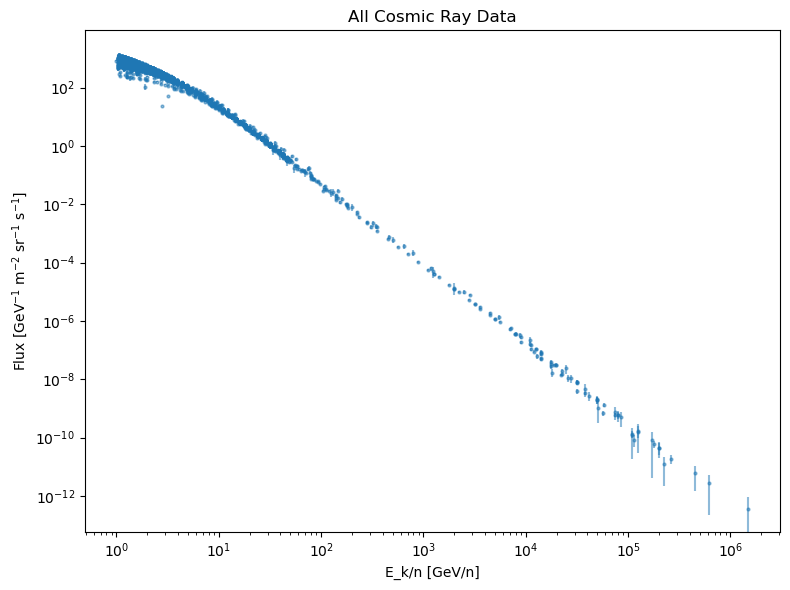

In [14]:
# Plot all data (log-log)
plt.figure(figsize=(8, 6))
plt.errorbar(df["<E>"], df["y"], yerr=df["yerrtot_mean"], fmt='o', ms=2, alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("E_k/n [GeV/n]")
plt.ylabel(r"Flux [GeV$^{-1}$ m$^{-2}$ sr$^{-1}$ s$^{-1}$]")
plt.title("All Cosmic Ray Data")
plt.tight_layout()
plt.savefig("results/figures/01_all_data_loglog.png", dpi=300)
plt.show()

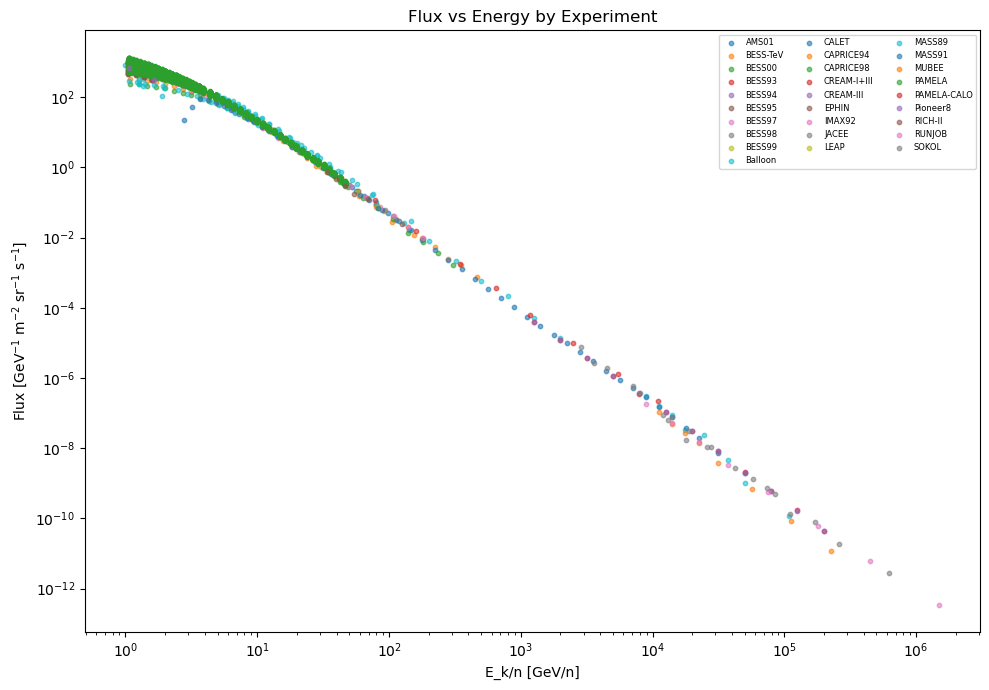

In [15]:
# Plot by experiment
plt.figure(figsize=(10, 7))

for name, group in df.groupby("EXP"):
    plt.scatter(group["<E>"], group["y"], s=10, alpha=0.6, label=name)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("E_k/n [GeV/n]")
plt.ylabel(r"Flux [GeV$^{-1}$ m$^{-2}$ sr$^{-1}$ s$^{-1}$]")
plt.title("Flux vs Energy by Experiment")
plt.legend(fontsize=6, ncol=3)
plt.tight_layout()
plt.savefig("results/figures/02_experiment_colored.png", dpi=300)
plt.show()

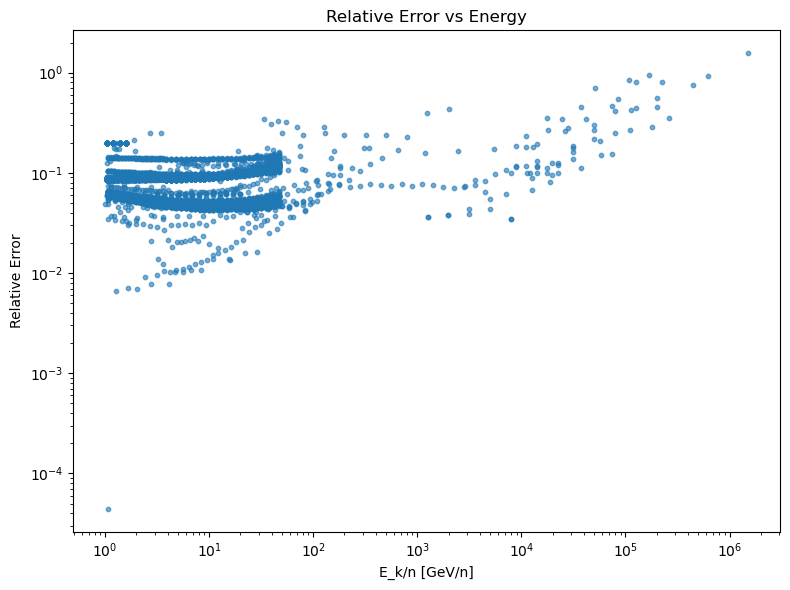

In [16]:
# Relative error plot
relative_error = df["yerrtot_mean"] / df["y"]

plt.figure(figsize=(8, 6))
plt.scatter(df["<E>"], relative_error, s=10, alpha=0.6)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("E_k/n [GeV/n]")
plt.ylabel("Relative Error")
plt.title("Relative Error vs Energy")
plt.tight_layout()
plt.savefig("results/figures/03_relative_error.png", dpi=300)
plt.show()

In [17]:
# Weighted mean flux between 20 and 30 GeV
band = df[(df["<E>"] > 20) & (df["<E>"] < 30)].copy()

mean_flux = band["y"].mean()
weighted_mean_flux = np.average(band["y"], weights=1 / band["yerrtot_mean"]**2)
weighted_mean_err = np.sqrt(1 / np.sum(1 / band["yerrtot_mean"]**2))

print("Simple mean flux (20-30 GeV/n):", mean_flux)
print("Weighted mean flux (20-30 GeV/n):", weighted_mean_flux)
print("Weighted mean error:", weighted_mean_err)

Simple mean flux (20-30 GeV/n): 2.113822134078212
Weighted mean flux (20-30 GeV/n): 1.758029159313344
Weighted mean error: 0.005814895984250191


In [18]:
# Apply energy cut
df_cut = df[df["<E>"] > ENERGY_THRESHOLD].copy()

E = df_cut["<E>"].values
y = df_cut["y"].values
yerr = df_cut["yerrtot_mean"].values

print("Number of points above threshold:", len(df_cut))

Number of points above threshold: 790


In [19]:
# Define deterministic power-law model
def power_law(E, F0, p):
    """
    Power-law model:
    F(E) = F0 * E^(-p)
    """
    return F0 * np.power(E, -p)

In [20]:
# Run deterministic fit

initial_guess = [14000.0, 2.7]

popt, pcov = curve_fit(power_law, E, y, p0=initial_guess, maxfev=20000)

F0_fit, p_fit = popt

print("Deterministic fit results")
print("F0 =", F0_fit)
print("p  =", p_fit)

Deterministic fit results
F0 = 14467.535604764693
p  = 2.74920044829796


In [21]:
# Compute chi-square and p-value
def chi2_value(E, y, yerr, F0, p):
    model_y = power_law(E, F0, p)
    return np.sum(((y - model_y) / yerr) ** 2)

chi2 = chi2_value(E, y, yerr, F0_fit, p_fit)
ndof = len(E) - 2
red_chi2 = chi2 / ndof
pvalue = ss.chi2.sf(chi2, ndof)

print("chi2 =", chi2)
print("ndof =", ndof)
print("reduced chi2 =", red_chi2)
print("p-value =", pvalue)

chi2 = 1362.729948160053
ndof = 788
reduced chi2 = 1.7293527260914379
p-value = 2.2999458310138073e-33


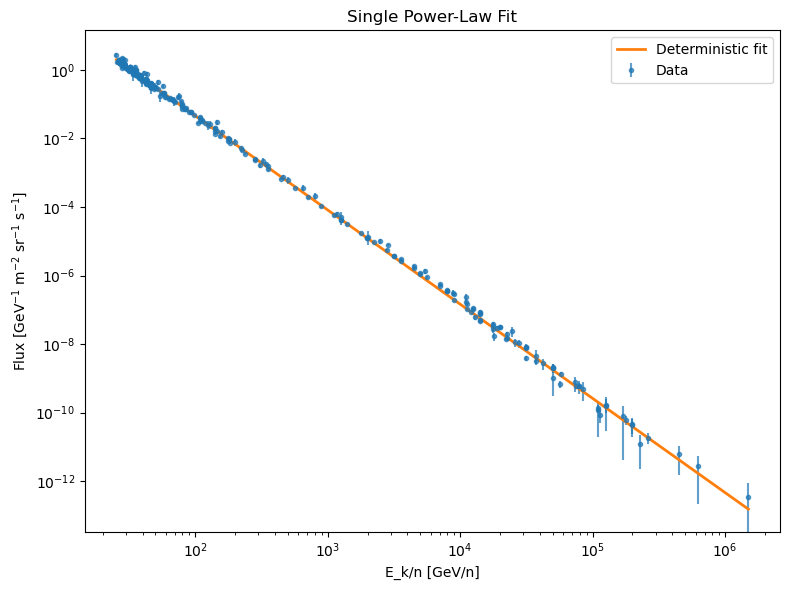

In [22]:
# Plot deterministic fit
E_sorted = np.sort(E)

plt.figure(figsize=(8, 6))
plt.errorbar(E, y, yerr=yerr, fmt='o', ms=3, alpha=0.7, label="Data")
plt.plot(E_sorted, power_law(E_sorted, F0_fit, p_fit), lw=2, label="Deterministic fit")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("E_k/n [GeV/n]")
plt.ylabel(r"Flux [GeV$^{-1}$ m$^{-2}$ sr$^{-1}$ s$^{-1}$]")
plt.title("Single Power-Law Fit")
plt.legend()
plt.tight_layout()
plt.savefig("results/figures/04_curve_fit.png", dpi=300)
plt.show()

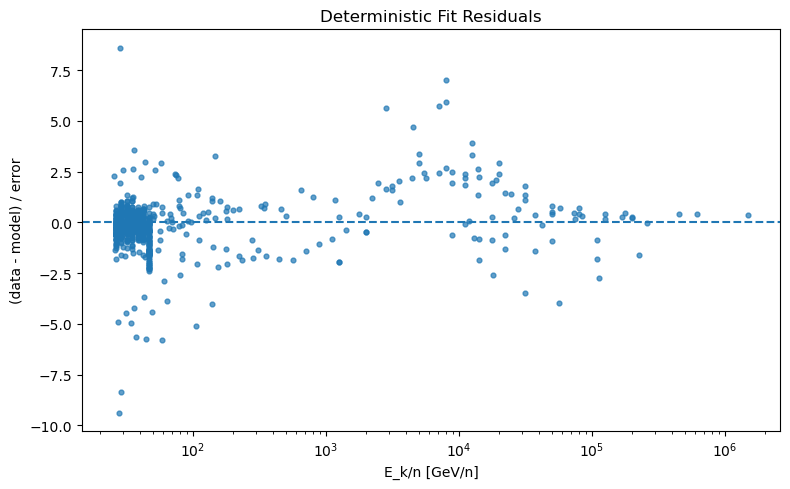

In [23]:
# Plot residuals for deterministic fit
residuals_det = (y - power_law(E, F0_fit, p_fit)) / yerr

plt.figure(figsize=(8, 5))
plt.scatter(E, residuals_det, s=12, alpha=0.7)
plt.axhline(0, linestyle='--')
plt.xscale("log")
plt.xlabel("E_k/n [GeV/n]")
plt.ylabel("(data - model) / error")
plt.title("Deterministic Fit Residuals")
plt.tight_layout()
plt.savefig("results/figures/05_residuals_curve_fit.png", dpi=300)
plt.show()

In [24]:
# Define Bayesian model functions
def total_error(params, y, yerr):
    """
    Total variance including extra fractional scatter f.
    """
    F0, p, f = params
    return np.sqrt(yerr**2 + (f * y)**2)


def lnprior(params):
    """
    Priors on F0, p, f
    """
    F0, p, f = params

    if 1e4 < F0 < 2e4 and 2.0 < p < 4.0 and 0.0 < f < 0.5:
        return np.log(1.0 / F0) + np.log(1.0 / (f + 1e-12))
    return -np.inf


def lnlike(params, x, y, yerr):
    """
    Gaussian log-likelihood
    """
    F0, p, f = params
    model_y = power_law(x, F0, p)
    err = total_error(params, y, yerr)

    return -0.5 * np.sum(((y - model_y) ** 2) / (err ** 2) + np.log(err ** 2))


def lnpost(params, x, y, yerr):
    """
    Posterior = prior + likelihood
    """
    lp = lnprior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(params, x, y, yerr)

In [25]:
# RUN MCMC
ndim = 3
initial = np.array([13000.0, 2.7, 0.05])

# Initialize walkers near the starting point
pos = initial + 1e-2 * np.random.randn(NWALKERS, ndim)

sampler = emcee.EnsembleSampler(NWALKERS, ndim, lnpost, args=(E, y, yerr))

sampler.run_mcmc(pos, NSTEPS, progress=True)

100%|██████████| 3000/3000 [00:30<00:00, 99.61it/s] 


State([[1.34842893e+04 2.73619559e+00 4.16740569e-02]
 [1.36946419e+04 2.73893100e+00 4.69368894e-02]
 [1.31819279e+04 2.73098292e+00 4.72553427e-02]
 [1.33174875e+04 2.73524972e+00 3.73158435e-02]
 [1.33709682e+04 2.73374054e+00 5.07842586e-02]
 [1.33663307e+04 2.73470899e+00 4.18259392e-02]
 [1.35026790e+04 2.73505775e+00 4.99095189e-02]
 [1.33574420e+04 2.73262767e+00 4.19585917e-02]
 [1.34412058e+04 2.73621792e+00 3.96192137e-02]
 [1.35994146e+04 2.73824856e+00 4.60999465e-02]
 [1.35176620e+04 2.73756108e+00 4.19802740e-02]
 [1.33511010e+04 2.73414510e+00 4.42788829e-02]
 [1.33537418e+04 2.73424527e+00 4.63840830e-02]
 [1.30981030e+04 2.73108622e+00 4.71558738e-02]
 [1.34461017e+04 2.73448147e+00 4.29387350e-02]
 [1.33451192e+04 2.73336391e+00 4.75135784e-02]
 [1.34711548e+04 2.73586524e+00 4.58249493e-02]
 [1.33043685e+04 2.73368141e+00 4.85171772e-02]
 [1.34525679e+04 2.73632466e+00 4.62538952e-02]
 [1.32407357e+04 2.73171809e+00 4.41830572e-02]
 [1.35636386e+04 2.73719335e+00 4.

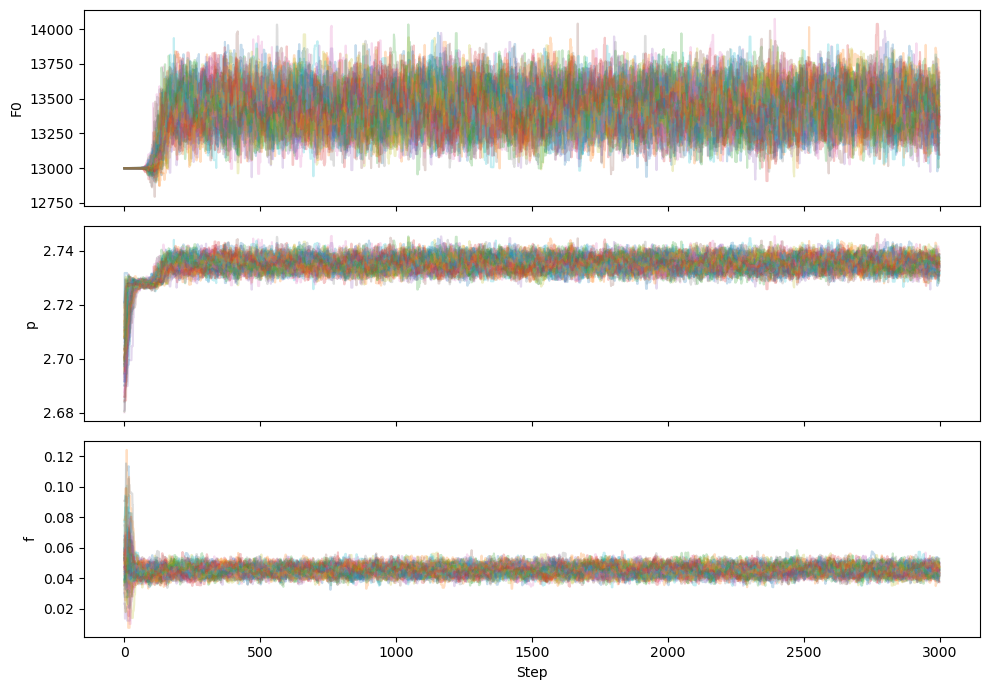

In [26]:
# Trace plots
labels = ["F0", "p", "f"]
chain = sampler.get_chain()

fig, axes = plt.subplots(len(labels), 1, figsize=(10, 7), sharex=True)

for i, label in enumerate(labels):
    axes[i].plot(chain[:, :, i], alpha=0.25)
    axes[i].set_ylabel(label)

axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.savefig("results/figures/06_mcmc_traces.png", dpi=300)
plt.show()

In [27]:
# Flatten chain after burn-in
flat_samples = sampler.get_chain(discard=BURNIN, thin=THIN, flat=True)

print("Posterior sample shape:", flat_samples.shape)

Posterior sample shape: (14080, 3)


In [28]:
#Posterior summary
q16, q50, q84 = np.percentile(flat_samples, [16, 50, 84], axis=0)

F0_median, p_median, f_median = q50

F0_minus, p_minus, f_minus = q50 - q16
F0_plus, p_plus, f_plus = q84 - q50

print("Bayesian posterior summary")
print(f"F0 = {F0_median:.6f} (-{F0_minus:.6f}, +{F0_plus:.6f})")
print(f"p  = {p_median:.6f} (-{p_minus:.6f}, +{p_plus:.6f})")
print(f"f  = {f_median:.6f} (-{f_minus:.6f}, +{f_plus:.6f})")
print("Mean acceptance fraction =", np.mean(sampler.acceptance_fraction))

Bayesian posterior summary
F0 = 13435.343341 (-137.390231, +139.525715)
p  = 2.735370 (-0.002417, +0.002483)
f  = 0.045150 (-0.003040, +0.003200)
Mean acceptance fraction = 0.64228125


In [29]:
# TRY AUTO CORELATION TIME
try:
    tau = sampler.get_autocorr_time()
    print("Autocorrelation time:", tau)
except Exception as e:
    print("Autocorrelation time could not be estimated reliably.")
    print("Reason:", e)

Autocorrelation time could not be estimated reliably.
Reason: The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [63.83316934 63.87222362 32.49195602]


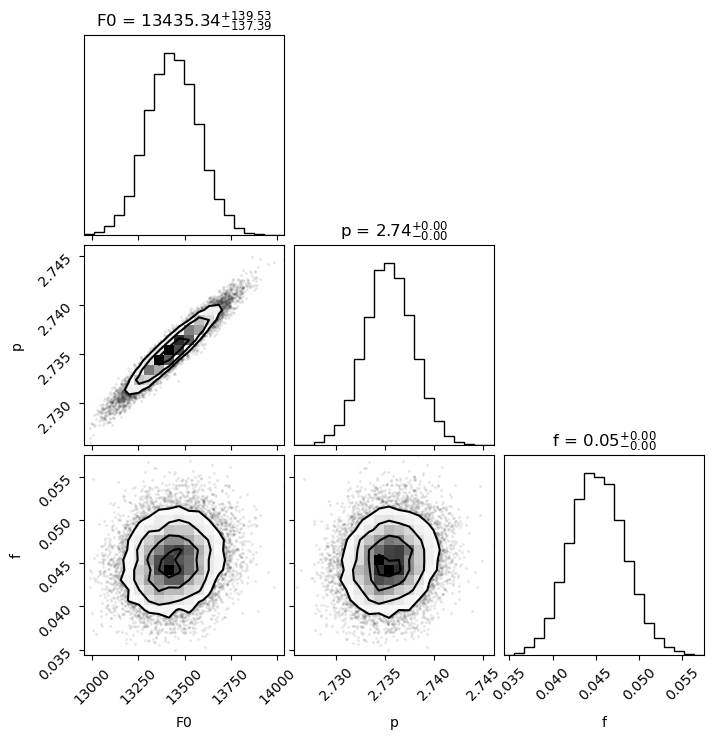

In [30]:
#CORNER PLOT
fig = corner.corner(flat_samples, labels=labels, show_titles=True)
fig.savefig("results/figures/07_corner_plot.png", dpi=300)
plt.show()

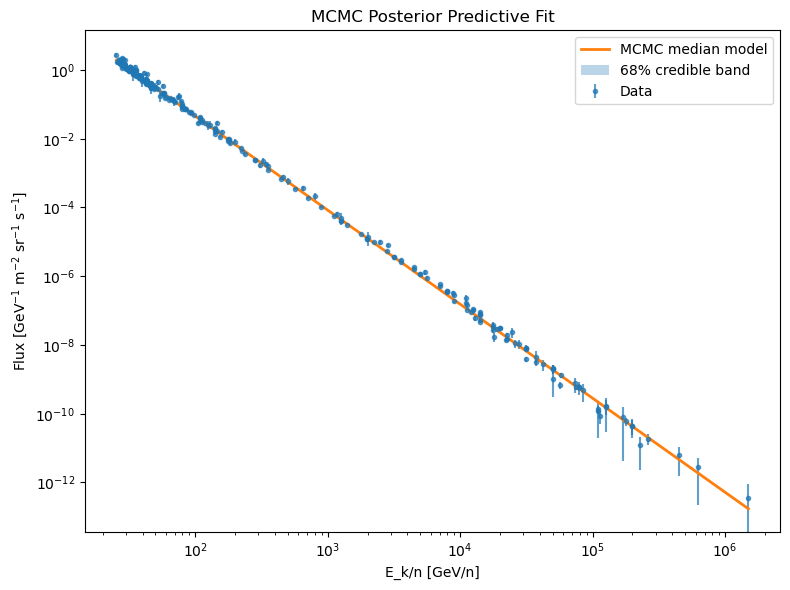

In [31]:
# Posterior predictive band
plt.figure(figsize=(8, 6))
plt.errorbar(E, y, yerr=yerr, fmt='o', ms=3, alpha=0.7, label="Data")

E_sorted = np.sort(E)

# Draw random posterior samples
rng = np.random.default_rng(42)
n_draws = min(300, len(flat_samples))
draw_idx = rng.choice(len(flat_samples), size=n_draws, replace=False)

model_curves = []
for idx in draw_idx:
    F0_draw, p_draw, f_draw = flat_samples[idx]
    model_curves.append(power_law(E_sorted, F0_draw, p_draw))

model_curves = np.array(model_curves)

y_med = np.median(model_curves, axis=0)
y_low = np.percentile(model_curves, 16, axis=0)
y_high = np.percentile(model_curves, 84, axis=0)

plt.plot(E_sorted, y_med, lw=2, label="MCMC median model")
plt.fill_between(E_sorted, y_low, y_high, alpha=0.3, label="68% credible band")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("E_k/n [GeV/n]")
plt.ylabel(r"Flux [GeV$^{-1}$ m$^{-2}$ sr$^{-1}$ s$^{-1}$]")
plt.title("MCMC Posterior Predictive Fit")
plt.legend()
plt.tight_layout()
plt.savefig("results/figures/08_mcmc_predictive_band.png", dpi=300)
plt.show()

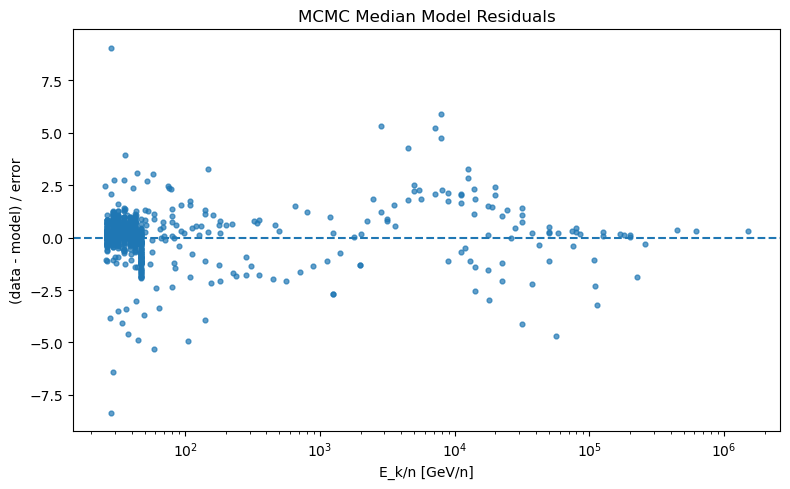

In [32]:
# Residuals for MCMC median modeL
residuals_mcmc = (y - power_law(E, F0_median, p_median)) / yerr

plt.figure(figsize=(8, 5))
plt.scatter(E, residuals_mcmc, s=12, alpha=0.7)
plt.axhline(0, linestyle='--')
plt.xscale("log")
plt.xlabel("E_k/n [GeV/n]")
plt.ylabel("(data - model) / error")
plt.title("MCMC Median Model Residuals")
plt.tight_layout()
plt.savefig("results/figures/09_residuals_mcmc.png", dpi=300)
plt.show()

In [33]:
# Save summary text file
summary_path = "results/tables/fit_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("Bayesian Cosmic Ray Spectrum Analysis Summary\n")
    f.write("=" * 55 + "\n\n")

    f.write("Weighted mean flux between 20 and 30 GeV/n\n")
    f.write(f"Simple mean flux: {mean_flux:.6f}\n")
    f.write(f"Weighted mean flux: {weighted_mean_flux:.6f}\n")
    f.write(f"Weighted mean error: {weighted_mean_err:.6f}\n\n")

    f.write("Deterministic single power-law fit\n")
    f.write(f"F0 = {F0_fit:.6f}\n")
    f.write(f"p  = {p_fit:.6f}\n")
    f.write(f"chi2 = {chi2:.6f}\n")
    f.write(f"ndof = {ndof}\n")
    f.write(f"reduced chi2 = {red_chi2:.6f}\n")
    f.write(f"p-value = {pvalue:.6e}\n\n")

    f.write("Bayesian MCMC posterior summary\n")
    f.write(f"F0 = {F0_median:.6f} (-{F0_minus:.6f}, +{F0_plus:.6f})\n")
    f.write(f"p  = {p_median:.6f} (-{p_minus:.6f}, +{p_plus:.6f})\n")
    f.write(f"f  = {f_median:.6f} (-{f_minus:.6f}, +{f_plus:.6f})\n")
    f.write(f"Mean acceptance fraction = {np.mean(sampler.acceptance_fraction):.4f}\n")

print(f"Summary saved to: {summary_path}")

Summary saved to: results/tables/fit_summary.txt


In [34]:
# Final interpretation print

print("Analysis complete.\n")

print("Interpretation:")
print("- The deterministic fit tests whether a single power law is statistically adequate.")
print("- If reduced chi2 is much larger than 1 and p-value is very small, the fit is poor.")
print("- The Bayesian model adds an extra scatter term f.")
print("- If f is nonzero, that suggests extra variance beyond quoted measurement errors.")
print("- This may come from experiment-to-experiment differences or spectral complexity.")

Analysis complete.

Interpretation:
- The deterministic fit tests whether a single power law is statistically adequate.
- If reduced chi2 is much larger than 1 and p-value is very small, the fit is poor.
- The Bayesian model adds an extra scatter term f.
- If f is nonzero, that suggests extra variance beyond quoted measurement errors.
- This may come from experiment-to-experiment differences or spectral complexity.
